# 06 - Grad-CAM Explainability

TODO: fill in this notebook.

In [5]:
import sys
from pathlib import Path

sys.path.append('../src')

from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
VAL_DIR = Path('..') / 'data' / 'processed' / 'val'

val_datagen = ImageDataGenerator(rescale=1.0 / 255.0)
val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
)

print('Class indices:', val_generator.class_indices)
print('Validation images:', val_generator.samples)

Found 320 images belonging to 2 classes.
Class indices: {'Fake Notes': 0, 'Real Notes': 1}
Validation images: 320


In [2]:
from tensorflow.keras.models import load_model

model = load_model("../models/mobilenetv2_fake_currency.keras")

# The MobileNetV2 backbone is nested inside your model
base_model = model.get_layer("mobilenetv2_1.00_224")

# Print the last few layers to find the right one
for layer in base_model.layers[-10:]:
    print(layer.name, layer.output.shape)

block_16_expand_BN (None, 7, 7, 960)
block_16_expand_relu (None, 7, 7, 960)
block_16_depthwise (None, 7, 7, 960)
block_16_depthwise_BN (None, 7, 7, 960)
block_16_depthwise_relu (None, 7, 7, 960)
block_16_project (None, 7, 7, 320)
block_16_project_BN (None, 7, 7, 320)
Conv_1 (None, 7, 7, 1280)
Conv_1_bn (None, 7, 7, 1280)
out_relu (None, 7, 7, 1280)


In [11]:
import tensorflow as tf
import numpy as np

def make_gradcam_heatmap(img_array, model, base_model_name="mobilenetv2_1.00_224", last_conv_layer_name="out_relu"):
    base_model = model.get_layer(base_model_name)
    if last_conv_layer_name != "out_relu":
        raise ValueError("This model supports Grad-CAM from the out_relu layer only")

    with tf.GradientTape() as tape:
        conv_outputs = base_model(img_array, training=False)
        predictions = conv_outputs

        for layer in model.layers:
            if layer is base_model or isinstance(layer, tf.keras.layers.InputLayer):
                continue
            predictions = layer(predictions, training=False)

        loss = predictions[:, 0]  # single sigmoid output

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

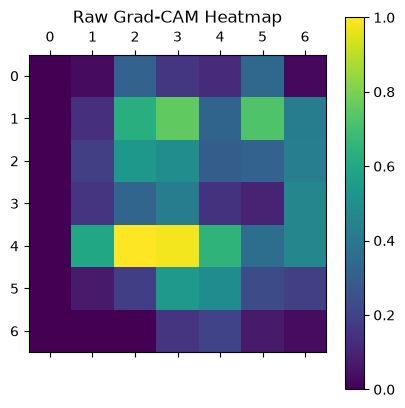

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Pick one misclassified image to investigate, or fall back to the first validation image.
val_generator.reset()
y_true = val_generator.classes
y_pred_probs = model.predict(val_generator, verbose=0).ravel()
y_pred = (y_pred_probs > 0.5).astype(int)
misclassified_idx = np.where(y_true != y_pred)[0]
sample_idx = misclassified_idx[0] if len(misclassified_idx) else 0
sample_path = val_generator.filepaths[sample_idx]

img = Image.open(sample_path).convert("RGB").resize((224, 224))
img_array = np.expand_dims(np.array(img) / 255.0, axis=0)

heatmap = make_gradcam_heatmap(img_array, model)

plt.matshow(heatmap)
plt.title("Raw Grad-CAM Heatmap")
plt.colorbar()
plt.show()

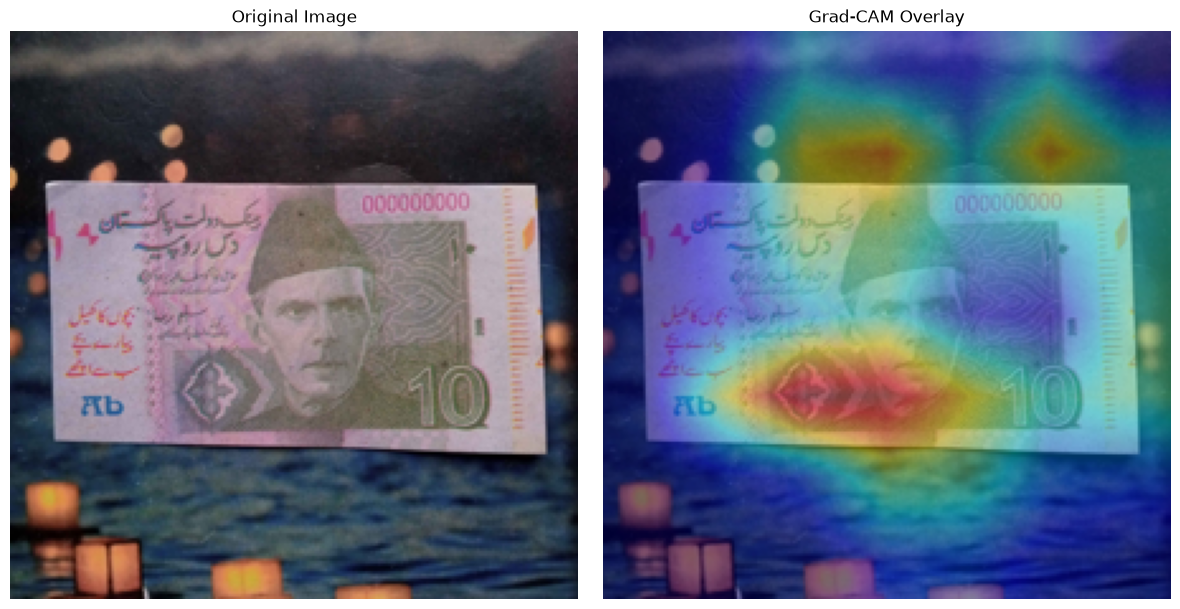

In [13]:
import cv2

def overlay_heatmap(original_img, heatmap, alpha=0.4):
    heatmap_resized = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    
    overlayed = heatmap_colored * alpha + original_img * (1 - alpha)
    return overlayed.astype(np.uint8)

original_np = np.array(img)  # the 224x224 PIL image from before, as numpy array
overlayed_img = overlay_heatmap(original_np, heatmap)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(original_np)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(overlayed_img)
axes[1].set_title("Grad-CAM Overlay")
axes[1].axis("off")

plt.tight_layout()
plt.show()

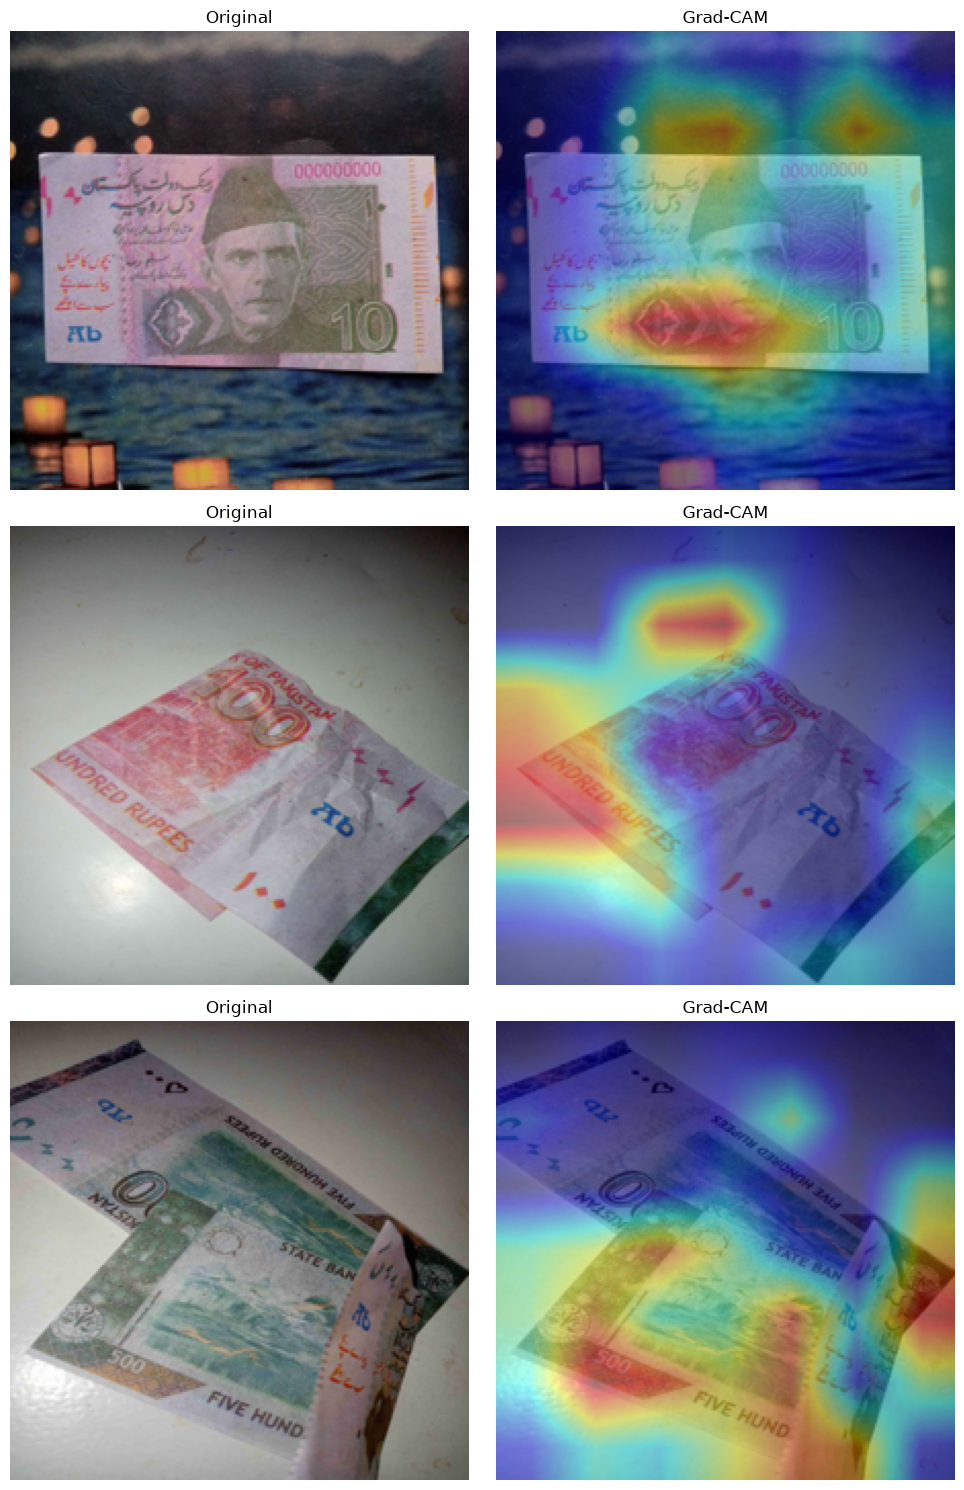

In [14]:
fig, axes = plt.subplots(3, 2, figsize=(10, 15))

for i in range(3):
    sample_path = val_generator.filepaths[misclassified_idx[i]]
    img = Image.open(sample_path).convert("RGB").resize((224, 224))
    img_array = np.expand_dims(np.array(img) / 255.0, axis=0)
    
    heatmap = make_gradcam_heatmap(img_array, model)
    original_np = np.array(img)
    overlayed = overlay_heatmap(original_np, heatmap)
    
    axes[i, 0].imshow(original_np)
    axes[i, 0].set_title("Original")
    axes[i, 0].axis("off")
    
    axes[i, 1].imshow(overlayed)
    axes[i, 1].set_title("Grad-CAM")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()